## OBV Strategy

### QVI 김창균

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from datetime import date, timedelta
from pykrx import stock

## 주가 데이터 불러오기

In [2]:
def loadStockPrice(num_of_days_to_see, stockTicker):
    today = date.today().strftime('%Y%m%d')
    today_gap = (date.today() - timedelta(num_of_days_to_see)).strftime('%Y%m%d')
    stock_history = stock.get_market_ohlcv_by_date(fromdate=today_gap, todate=today, ticker=stockTicker)
    
    #data_without_date = stock_history.get(['시가','고가','저가','종가','거래량']).values
    
    return stock_history

### LoadStockPrice 함수에서 첫 번째 변수는 현재로 부터 과거 몇 일 까지 데이터를 불러올지 정하는 input value입니다

In [3]:
#loadStockPrice(20, '005930')

### 회사 선택

In [4]:
ticker_df = pd.read_excel('data/ticker.xlsx')

In [5]:
ticker_df = ticker_df.apply(lambda x: x.str.strip("A"), axis = 1)

In [7]:
del ticker_df['산업']

In [8]:
ticker = ticker_df['ticker']

In [9]:
company_list = ticker_df['기업명'].to_list()

In [10]:
company_list_df = pd.DataFrame(company_list, columns = ['Company Name'])

,Company Name
0,SGC에너지
1,롯데케미칼
2,한세예스24홀딩스
3,인터파크
4,마크로젠
5,네오위즈홀딩스
6,조광ILI
7,룽투코리아
8,컴투스홀딩스
9,한국전자금융


## OBV 거래량 지표를 이용한 투자전략

In [11]:
def calculate_OBV(data):
    OBV = []
    OBV.append(0)

    for i in range(1, len(data.price)):
    
        if data.price[i] > data.price[i-1]: 
            OBV.append(OBV[-1] + data.volume[i]) 
            
        elif data.price[i] < data.price[i-1]:
            OBV.append( OBV[-1] - data.volume[i])
        
        else:
            OBV.append(OBV[-1])

    return OBV

In [35]:
def OBV_signal(data, col1, col2):
    # signal에서 보유 : 1, 미보유 : 0으로 표기 / flag는 보유상태 의미
    signal = [1, 1] 
    flag = 1
    
    # D-1일, D-0일의 데이터를 보고 D+1일의 보유/미보유 여부를 결정하는 것
    # 따라서 1일차, 2일차는 그냥 들고있다고 처리하고, 마지막날 전날까지만 데이터 확인하는것으로
    
    for i in range(1,len(data)-1):

    #OBV가 시그널 상향돌파 + 주식 미보유 -> 산다
        if data[col1][i] > data[col2][i]\
        and data[col1][i-1] <= data[col2][i-1]\
        and flag == 0:
            signal.append(1)
            flag = 1
            
    #OBV가 시그널 하향돌파 + 주식 보유 -> 판다
        elif data[col1][i] < data[col2][i]\
        and data[col1][i-1] >= data[col2][i-1]\
        and flag == 1:
            signal.append(0)
            flag = 0
            
        else:
            signal.append(signal[-1])
            
    return signal


In [33]:
def data_loader(days, index):
    
    data = loadStockPrice(days, ticker[index])
    data = data[['종가', '거래량']]
    data.columns = ['price', 'volume']
    data.index.name = 'Date'
    data['return'] = data['price'].pct_change()
    data['OBV'] = calculate_OBV(data)
    data['OBV_EMA'] = data['OBV'].ewm(com=20).mean()
    data['OBV_signal'] = OBV_signal(data, 'OBV', 'OBV_EMA')
    data = data.dropna()
    data['cum_ret'] = (data['return'] + 1).cumprod()-1
    
    return data

In [ ]:
def buy_sell(signal, col1, col2):
    
    sigPriceBuy = []
    sigPriceSell = []
    flag = -1 #A flag for the trend upward/downward

    #Loop through the length of the data set
    for i in range(0,len(signal)):

    #if OBV > OBV_EMA  and flag != 1 then buy else sell
        if signal[col1][i] > signal[col2][i] and flag != 1:
            sigPriceBuy.append(signal['price'][i])
            sigPriceSell.append(np.nan)
            flag = 1

    #else  if OBV < OBV_EMA  and flag != 0 then sell else buy
        elif signal[col1][i] < signal[col2][i] and flag != 0:    
            sigPriceSell.append(signal['price'][i])
            sigPriceBuy.append(np.nan)
            flag = 0

    #else   OBV == OBV_EMA  so append NaN 
        else: 
            sigPriceBuy.append(np.nan)
            sigPriceSell.append(np.nan)

    return (sigPriceBuy, sigPriceSell)

In [ ]:
def buy_sell_indicator(buy_df, sell_df):
    
    buy = buy_df.to_frame().dropna()
    sell = sell_df.to_frame().dropna()
    indicator_df = pd.merge(buy, sell, how='outer', on = 'Date')
    indicator_df = indicator_df.sort_index(ascending=True)
    
    return indicator_df

## 각 종목별로 가장 최근에 발생한 Signal을 보여주는 함수

In [ ]:
def Company_selector(company_index):
    
    data = data_loader(200, company_index)
    x = buy_sell(data, 'OBV','OBV_EMA')
    data['Buy_Signal_Price'] = x[0]
    data['Sell_Signal_Price'] = x[1]

    indicator_df = buy_sell_indicator(data['Buy_Signal_Price'], data['Sell_Signal_Price'])
    indicator_df.columns = [company_list[company_index]+'_Buy_Price', company_list[company_index]+'_Sell_Price' ]
    
    last_df = indicator_df.iloc[-1:,:]
    
    
    return last_df

## 주가 데이터에 매수/매도 Signal 띄워주는 함수

In [ ]:
def stock_plot(company_index):
    
    data = data_loader(200, company_index)
    x = buy_sell(data, 'OBV','OBV_EMA' )
    data['Buy_Signal_Price'], data['Sell_Signal_Price'] = x[0], x[1]
    
    plt.figure(figsize=(20,10)) 
    plt.scatter(data.index, data['Buy_Signal_Price'], color = 'green', label='Buy Signal', marker = '^', alpha = 1)
    plt.scatter(data.index, data['Sell_Signal_Price'], color = 'red', label='Sell Signal', marker = 'v', alpha = 1)
    plt.plot( data['price'], label='Close Price', alpha = 0.35)
    plt.xticks(rotation=45)
    plt.title('The Stock Buy / Sell Signals')
    plt.xlabel('Date',fontsize=18)
    plt.ylabel('Price KRW (\)',fontsize=18)
    plt.legend( fontsize = 16, loc='upper right')
    output = plt.show()
    
    return output

In [ ]:
empty_df = pd.DataFrame(index=data_loader(200, 0).index, columns={'empty'})
total_df = pd.merge(empty_df, Company_selector(0), how = 'outer', on = 'Date')

In [72]:
def backtest_engine(data):
    OBV_return = (data['return'] * data['OBV_signal']).to_frame()
    OBV_cum_ret = (OBV_return + 1).cumprod() - 1
    
    plt.figure(figsize=(7,4))
    plt.plot(data['cum_ret'], label='buy & hold')
    plt.plot(OBV_cum_ret, label = 'Using OBV')
    plt.legend()
    plt.show()

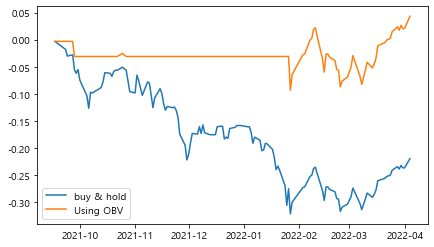

In [73]:
df = data_loader(200,2)
backtest_engine(df)

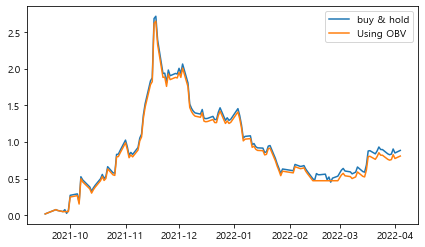

In [76]:
df2 = data_loader(200,18)
backtest_engine(df2)

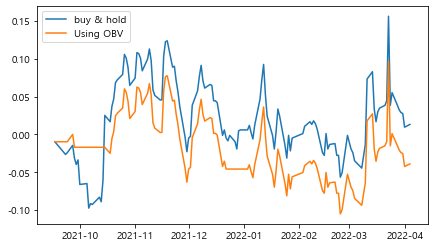

In [81]:
df3 = data_loader(200, 6)
backtest_engine(df3)

In [ ]:
df['obv_diff'] = df['OBV'] - df['OBV_EMA']
df['obv_lag1'] = df['obv_diff'].shift(1)
df['obv_lag3'] = df['obv_diff'].shift(3)
df['obv_lag5'] = df['obv_diff'].shift(5)
df['obv_lag10'] = df['obv_diff'].shift(10)

df1 = df[['return', 'obv_lag1', 'obv_lag3', 'obv_lag5', 'obv_lag10']]
df1.corr()

In [ ]:
df['obv_chg'] = df['OBV'].pct_change()
df['obv_chg_lag1'] = df['obv_chg'].shift(1)
df['obv_chg_lag3'] = df['obv_chg'].shift(3)
df['obv_chg_lag5'] = df['obv_chg'].shift(5)
df['obv_chg_lag10'] = df['obv_chg'].shift(10)

df2 = df[['return', 'obv_chg_lag1', 'obv_chg_lag3', 'obv_chg_lag5', 'obv_chg_lag10']]
df2.corr()

In [ ]:
df['obv_diff_chg'] = df['obv_diff'].pct_change()
df['obv_diff_chg_lag1'] = df['obv_diff_chg'].shift(1)
df['obv_diff_chg_lag3'] = df['obv_diff_chg'].shift(3)
df['obv_diff_chg_lag5'] = df['obv_diff_chg'].shift(5)
df['obv_diff_chg_lag10'] = df['obv_diff_chg'].shift(10)

df3 = df[['return', 'obv_diff_chg_lag1', 'obv_diff_chg_lag3', 'obv_diff_chg_lag5', 'obv_diff_chg_lag10']]
df3.corr()

In [ ]:
# df_date = []

# for i in range(20):
    
#     df_date.append(dfs[i].index.date)

In [ ]:
#df_date.sort()